# Diagnosing Haar features

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import io
from skimage.color import rgb2gray
from skimage.util import img_as_ubyte
import cv2


### Loading and displaying the Haar images

We'll start by loading both the reference and a computed Haar stage image.

In [4]:
# Load both the stage image and the reference image
feat_dir = 'haar_features'
#stage_img = img_as_ubyte(rgb2gray(io.imread(f"{feat_dir}/stage_3/11.png")))
ref_path = 'annotation_img.jpg'
ref_img = io.imread(ref_path)
ref_img = img_as_ubyte(rgb2gray(ref_img)) # Want the image to be grayscaled

# Look at the stage image shape
#plt.imshow(stage_img)

offset_y = 50 
#stage_img = stage_img[offset_y:,:]

/tmp/ipykernel_15436/661310006.py:6: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(stage_img[ymin-1:ymax+2,xmin-1:xmax+2])


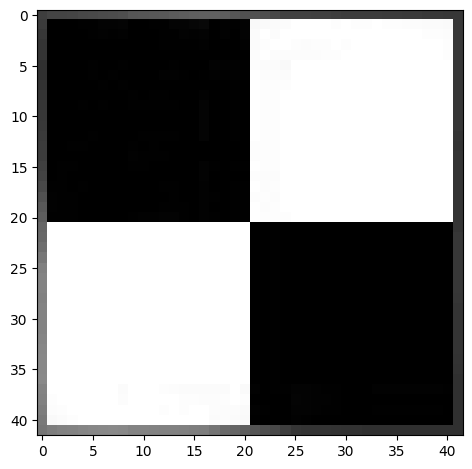

40 79 140 179
(np.int64(4), np.int64(7))
(np.int64(14), np.int64(17))


In [37]:

ys, xs = np.where((stage_img == 0) | (stage_img == 255))
coords = np.vstack((ys, xs)) # ys,xs due to standard convention of packages

# Get (y0,x0) and (y1,x1), slice and show image
ymin, xmin, ymax, xmax = np.concatenate((coords.min(axis=1), coords.max(axis=1)))
io.imshow(stage_img[ymin-1:ymax+2,xmin-1:xmax+2])
plt.show()
print(xmin,xmax,ymin+offset_y,ymax+offset_y)

y_slice, x_slice = ((ymin+offset_y)//10,(ymax+offset_y)//10),((xmin)//10,(xmax)//10)
print(x_slice)
print(y_slice)

We find, that the images have been upscaled by x10 (240x1200) // 10 -> (24x24x5). Slicing according to our chosen feature and resizing, we get:

/tmp/ipykernel_12876/145481216.py:7: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(sliced_img)


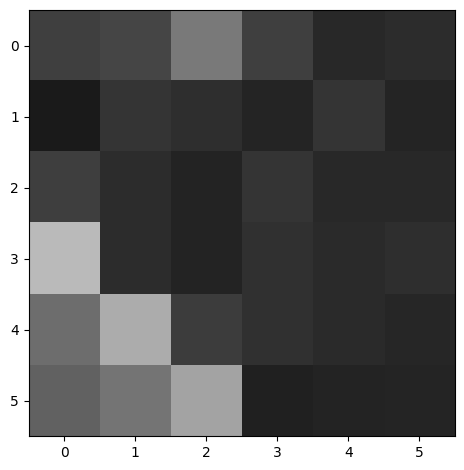

In [5]:
y_min = 14
y_max = 17 
x_min = 4
x_max = 7 

sliced_img = ref_img[y_min-1:y_max+2,x_min-1:x_max+2]
io.imshow(sliced_img)

### Compute integral image

In [6]:
#my sol 
integral_im = np.cumsum(sliced_img,axis=0)
integral_im = np.cumsum(integral_im,axis=1)
print(sliced_img)
print(integral_im)

[[ 63  69 122  63  41  44]
 [ 26  53  46  36  52  37]
 [ 62  44  35  52  40  40]
 [186  44  35  49  42  46]
 [109 172  61  49  42  38]
 [ 97 116 164  32  35  36]]
[[  63  132  254  317  358  402]
 [  89  211  379  478  571  652]
 [ 151  317  520  671  804  925]
 [ 337  547  785  985 1160 1327]
 [ 446  828 1127 1376 1593 1798]
 [ 543 1041 1504 1785 2037 2278]]


Now we compute the integral image using *np.cumsum*. We then visualize 

In [108]:
integral_im.shape
    

(6, 6)

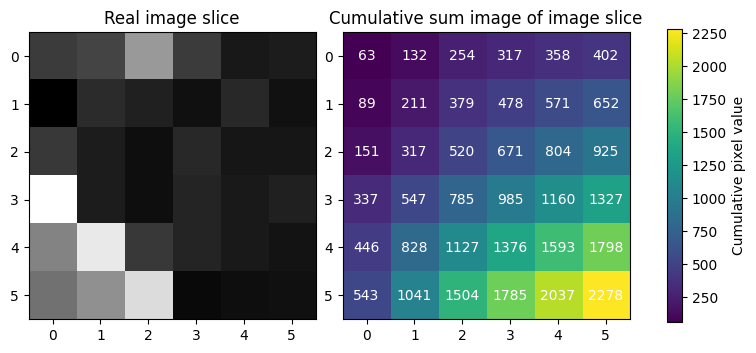

In [7]:

# Retrieve sliced image
# sliced_img = ref_img[ymin:ymax+1,xmin:xmax+1]

# Integral image options
# integral_img = cv2.integral(sliced_img)[1:,1:] # Padds boundary - hence we may remove the first row of y,x respectfully
integral_img = np.cumsum(np.cumsum(sliced_img, axis=0), axis=1)

# Visualize the sliced image along with its integral counterpart
fig, axes = plt.subplots(ncols=2, figsize=(8,8))
axes[0].imshow(sliced_img, cmap='gray')
axes[0].set_title('Real image slice')
axes[0].set_aspect('equal')
img = axes[1].imshow(integral_img, cmap='viridis')
axes[1].set_title('Cumulative sum image of image slice')
axes[1].set_aspect('equal')

# Write numbers on each pixel of cumsum image to gain extra insights
for (i, j), val in np.ndenumerate(integral_img):
    axes[1].text(j, i, f"{val}", ha='center', va='center', color='white', fontsize=10)

plt.tight_layout()
fig.colorbar(img, label='Cumulative pixel value', ax=axes, shrink=0.38)
plt.show()

### Compute Haar feature

We're now ready to compute our Haar feature. We first need to separate Haar regions accordingly. In our case, we're working with a four rectangle diagonal Haar feature, whose starting positions (top left corner) can be found as below:

In [8]:

# Retrieve w, h of the Haar regions
w, h = integral_img.shape[1], integral_img.shape[0]
w_reg, h_reg = w//2, h//2

# As regions are standard uniform, we may retrieve start positions of each region like:
# As regions are standard uniform, we may retrieve start positions of each region like:
start_positions = np.array([
    [(y, x) for x in np.linspace(start=1, stop=w_reg, num=2)]
    for y in np.linspace(start=1, stop=h_reg, num=2)]
).reshape(-1, 2)

print(start_positions)

[[1. 1.]
 [1. 3.]
 [3. 1.]
 [3. 3.]]


Now, we'll add some functions, that will help locate the corners of each Haar region, compute their individual summed area and finally compute the 4 region Haar feature.

In [9]:
def compute_integral_image(integral_img, y0, x0, w, h):
    """
        Computes the integral image within the bounding box represented by (y0,x0,w,h).

        :param numpy.ndarray integral_img:      The integral image input. Dimensions need to supercede those of the bounding box.
        :param int y0:                          Initial starting y position of bounding box.
        :param int x0:                          Initial starting x position of bounding box.
        :param int w:                           Width of bounding box.
        :param int h:                           Height of bounding box.
    """
    
    # Retrieve corners of bounding box
    pos1, pos2, pos3, pos4 = (y0-1, x0-1), (y0-1, x0-1+w-1),(y0-1+h-1, x0-1), (y0-1+h-1, x0-1+w-1)

    # Compute integral image
    A = integral_img[pos1[0], pos1[1]]
    B = integral_img[pos2[0], pos2[1]]
    C = integral_img[pos3[0], pos3[1]]
    D = integral_img[pos4[0], pos4[1]]
    print(f"A: {A}, B: {B}, C: {C}, D: {D}")
    return D + A - B - C

def compute_diagonal_feat(integral_img, start_positions, w_reg, h_reg):
    """
        Computes the diagonal Haar feature of a 
    """

    # Compute integral image for each square region
    regions = []
    for y,x in start_positions:
        print(f"checking start position: {y},{x}")
        reg_integral = compute_integral_image(integral_img, int(y), int(x), w_reg, h_reg)
        print(f"received integral: {reg_integral}")
        regions.append(reg_integral)
   
    # Compute Haar feature
    white_pixels = regions[1] + regions[2]
    black_pixels = regions[0] + regions[3]
    haar_feat =  white_pixels - black_pixels

    return haar_feat


Using the function, we can compute the value of the Haar feature.

In [10]:
haar_feat = compute_diagonal_feat(integral_img, start_positions, w_reg, h_reg)
print(f"The computed Haar feature of image slice = {haar_feat}")

checking start position: 1.0,1.0
A: 63, B: 254, C: 151, D: 520
received integral: 178
checking start position: 1.0,3.0
A: 254, B: 358, C: 520, D: 804
received integral: 180
checking start position: 3.0,1.0
A: 151, B: 520, C: 446, D: 1127
received integral: 312
checking start position: 3.0,3.0
A: 520, B: 804, C: 1127, D: 1593
received integral: 182
The computed Haar feature of image slice = 132


# Try across image

[[1. 1.]
 [1. 3.]
 [3. 1.]
 [3. 3.]]
[[1 1]
 [1 3]
 [3 1]
 [3 3]]
checking start position: 1,1
A: 62, B: 122, C: 116, D: 249
received integral: 73
checking start position: 1,3
A: 199, B: 273, C: 392, D: 541
received integral: 75
checking start position: 3,1
A: 194, B: 394, C: 261, D: 574
received integral: 113
checking start position: 3,3
A: 641, B: 947, C: 1002, D: 1395
received integral: 87
[[1 2]
 [1 4]
 [3 2]
 [3 4]]
checking start position: 1,2
A: 122, B: 199, C: 249, D: 392
received integral: 66
checking start position: 1,4
A: 273, B: 336, C: 541, D: 729
received integral: 125
checking start position: 3,2
A: 394, B: 641, C: 574, D: 1002
received integral: 181
checking start position: 3,4
A: 947, B: 1286, C: 1395, D: 1776
received integral: 42
[[1 3]
 [1 5]
 [3 3]
 [3 5]]
checking start position: 1,3
A: 199, B: 273, C: 392, D: 541
received integral: 75
checking start position: 1,5
A: 336, B: 423, C: 729, D: 996
received integral: 180
checking start position: 3,3
A: 641, B: 947, C:

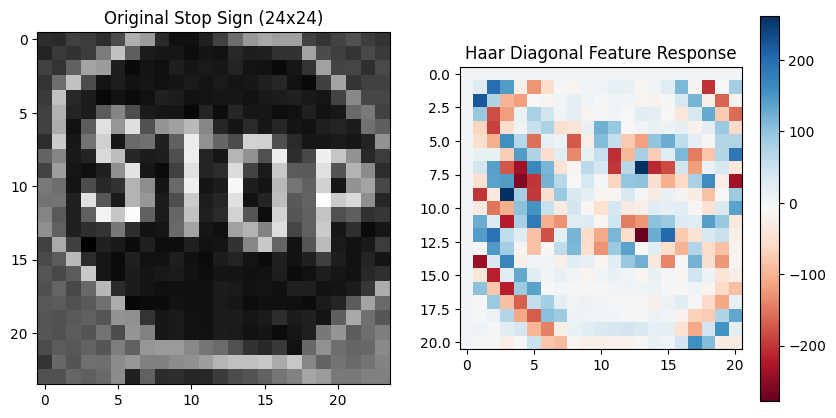

In [11]:

ref_path = 'annotation_img.jpg'
ref_img = io.imread(ref_path)
ref_img = img_as_ubyte(rgb2gray(ref_img)) # Want the image to be grayscaled
integral_img = cv2.integral(ref_img)[1:,1:]

# Retrieve w, h of the Haar regions
w, h = integral_img.shape[1], integral_img.shape[0]
w_rec, h_rec = 3, 3

# As regions are standard uniform, we may retrieve start positions of each region like:
start_positions = np.array([
    [(y, x) for x in np.linspace(start=1, stop=w_reg, num=2)]
    for y in np.linspace(start=1, stop=h_reg, num=2)]
).reshape(-1, 2)

print(start_positions)


# Parameters for your 4-feature (Total size 4x4)
w_reg, h_reg = 2, 2 
img_h, img_w = integral_img.shape

# The heatmap size: 24x24 image - 4x4 feature + 1 = 22x22
heatmap = np.zeros((img_h - 3, img_w - 3)) 

for y in range(1, img_h - 3): # Start at 1 because your function uses y0-1
    for x in range(1, img_w - 3):
        
        # Define the start positions for the 4 internal squares 
        # based on the current top-left (y, x)
        # [Top-Left, Top-Right, Bottom-Left, Bottom-Right]
        current_starts = np.array([
            (y, x),             # Region 0 (Black)
            (y, x + w_reg),     # Region 1 (White)
            (y + h_reg, x),     # Region 2 (White)
            (y + h_reg, x + w_reg) # Region 3 (Black)
        ])
        print(current_starts)
        # Use your function to get the Haar response at this location
        response = compute_diagonal_feat(integral_img, current_starts, w_reg, h_reg)
        
        # Store in heatmap (adjusting indices for 0-based array)
        heatmap[y, x] = response

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Stop Sign (24x24)")
plt.imshow(ref_img, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Haar Diagonal Feature Response")
plt.imshow(heatmap, cmap='RdBu') # Red-Blue shows positive/negative peaks
plt.colorbar()
plt.show()

In [12]:
integral_img.shape

(24, 24)

In [136]:
np.argwhere(heatmap==132)

array([[18, 20]])